In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jannatulferdaues/aquarium-fish-classification/Final (°_°)/Guppy/Copy of Copy of IMG_20250514_142836.jpg
/kaggle/input/datasets/jannatulferdaues/aquarium-fish-classification/Final (°_°)/Guppy/Copy of Copy of G2_grande.jpg
/kaggle/input/datasets/jannatulferdaues/aquarium-fish-classification/Final (°_°)/Guppy/Copy of Copy of Picsart_25-06-30_11-09-48-156.png
/kaggle/input/datasets/jannatulferdaues/aquarium-fish-classification/Final (°_°)/Guppy/Copy of Copy of Picsart_25-06-30_11-06-30-885.png
/kaggle/input/datasets/jannatulferdaues/aquarium-fish-classification/Final (°_°)/Guppy/Copy of Copy of Picsart_25-06-30_11-16-39-189.jpg
/kaggle/input/datasets/jannatulferdaues/aquarium-fish-classification/Final (°_°)/Guppy/Copy of Copy of Picsart_25-06-30_11-17-18-216.jpg
/kaggle/input/datasets/jannatulferdaues/aquarium-fish-classification/Final (°_°)/Guppy/Copy of Copy of Picsart_25-07-01_13-33-50-315.jpg
/kaggle/input/datasets/jannatulferdaues/aquarium-fish-classification/Fi

In [2]:
import os

base_path = "/kaggle/input/datasets/jannatulferdaues/aquarium-fish-classification/Final (°_°)"
print(os.listdir(base_path))  # muestra las clases (subcarpetas)

['Guppy', 'Gold', 'Bete', 'Oscar', 'Discuss', 'Cray']


In [1]:
from PIL import Image

img_path = "/kaggle/input/datasets/jannatulferdaues/aquarium-fish-classification/Final (°_°)/Cray/Copy of Copy of 640px-Cherax_destructor_(Cyan_yabby).jpg"

img = Image.open(img_path)
print("Resolución:", img.size)  # (ancho, alto)
print("formato de imagenes:",img.format)
print("Modo de imgs:",img.mode)

Resolución: (800, 600)
formato de imagenes: JPEG
Modo de imgs: RGB


In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 1. DEFINIR LAS TRANSFORMACIONES COMPLETAS
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. RUTA DEL DATASET
data_dir = "/kaggle/input/datasets/jannatulferdaues/aquarium-fish-classification/Final (°_°)"

# 3. CARGAR EL DATASET COMPLETO
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# 4. VER INFORMACIÓN DEL DATASET
print(f"Total de imágenes: {len(full_dataset)}")
print(f"Clases encontradas: {full_dataset.classes}")
print(f"Mapeo clase -> índice: {full_dataset.class_to_idx}")
print(f"Total de clases: {len(full_dataset.classes)}")

Total de imágenes: 1016
Clases encontradas: ['Bete', 'Cray', 'Discuss', 'Gold', 'Guppy', 'Oscar']
Mapeo clase -> índice: {'Bete': 0, 'Cray': 1, 'Discuss': 2, 'Gold': 3, 'Guppy': 4, 'Oscar': 5}
Total de clases: 6


🚀 Iniciando Data Augmentation...

📁 Procesando Bete: 194 imágenes originales
   Creando 9 variantes por imagen
   ✅ Bete: 1746 imágenes generadas

📁 Procesando Cray: 80 imágenes originales
   Creando 22 variantes por imagen
   ✅ Cray: 1760 imágenes generadas

📁 Procesando Discuss: 201 imágenes originales
   Creando 8 variantes por imagen
   ✅ Discuss: 1608 imágenes generadas

📁 Procesando Gold: 207 imágenes originales
   Creando 8 variantes por imagen
   ✅ Gold: 1656 imágenes generadas

📁 Procesando Guppy: 189 imágenes originales
   Creando 8 variantes por imagen
   ✅ Guppy: 1512 imágenes generadas

📁 Procesando Oscar: 145 imágenes originales
   Creando 13 variantes por imagen
   ✅ Oscar: 1885 imágenes generadas

📊 RESUMEN DE AUMENTACIÓN:
Bete:
  - Originales: 194
  - Generadas: 1746
  - Variantes por imagen: 9
Cray:
  - Originales: 80
  - Generadas: 1760
  - Variantes por imagen: 22
Discuss:
  - Originales: 201
  - Generadas: 1608
  - Variantes por imagen: 8
Gold:
  - Originales: 207


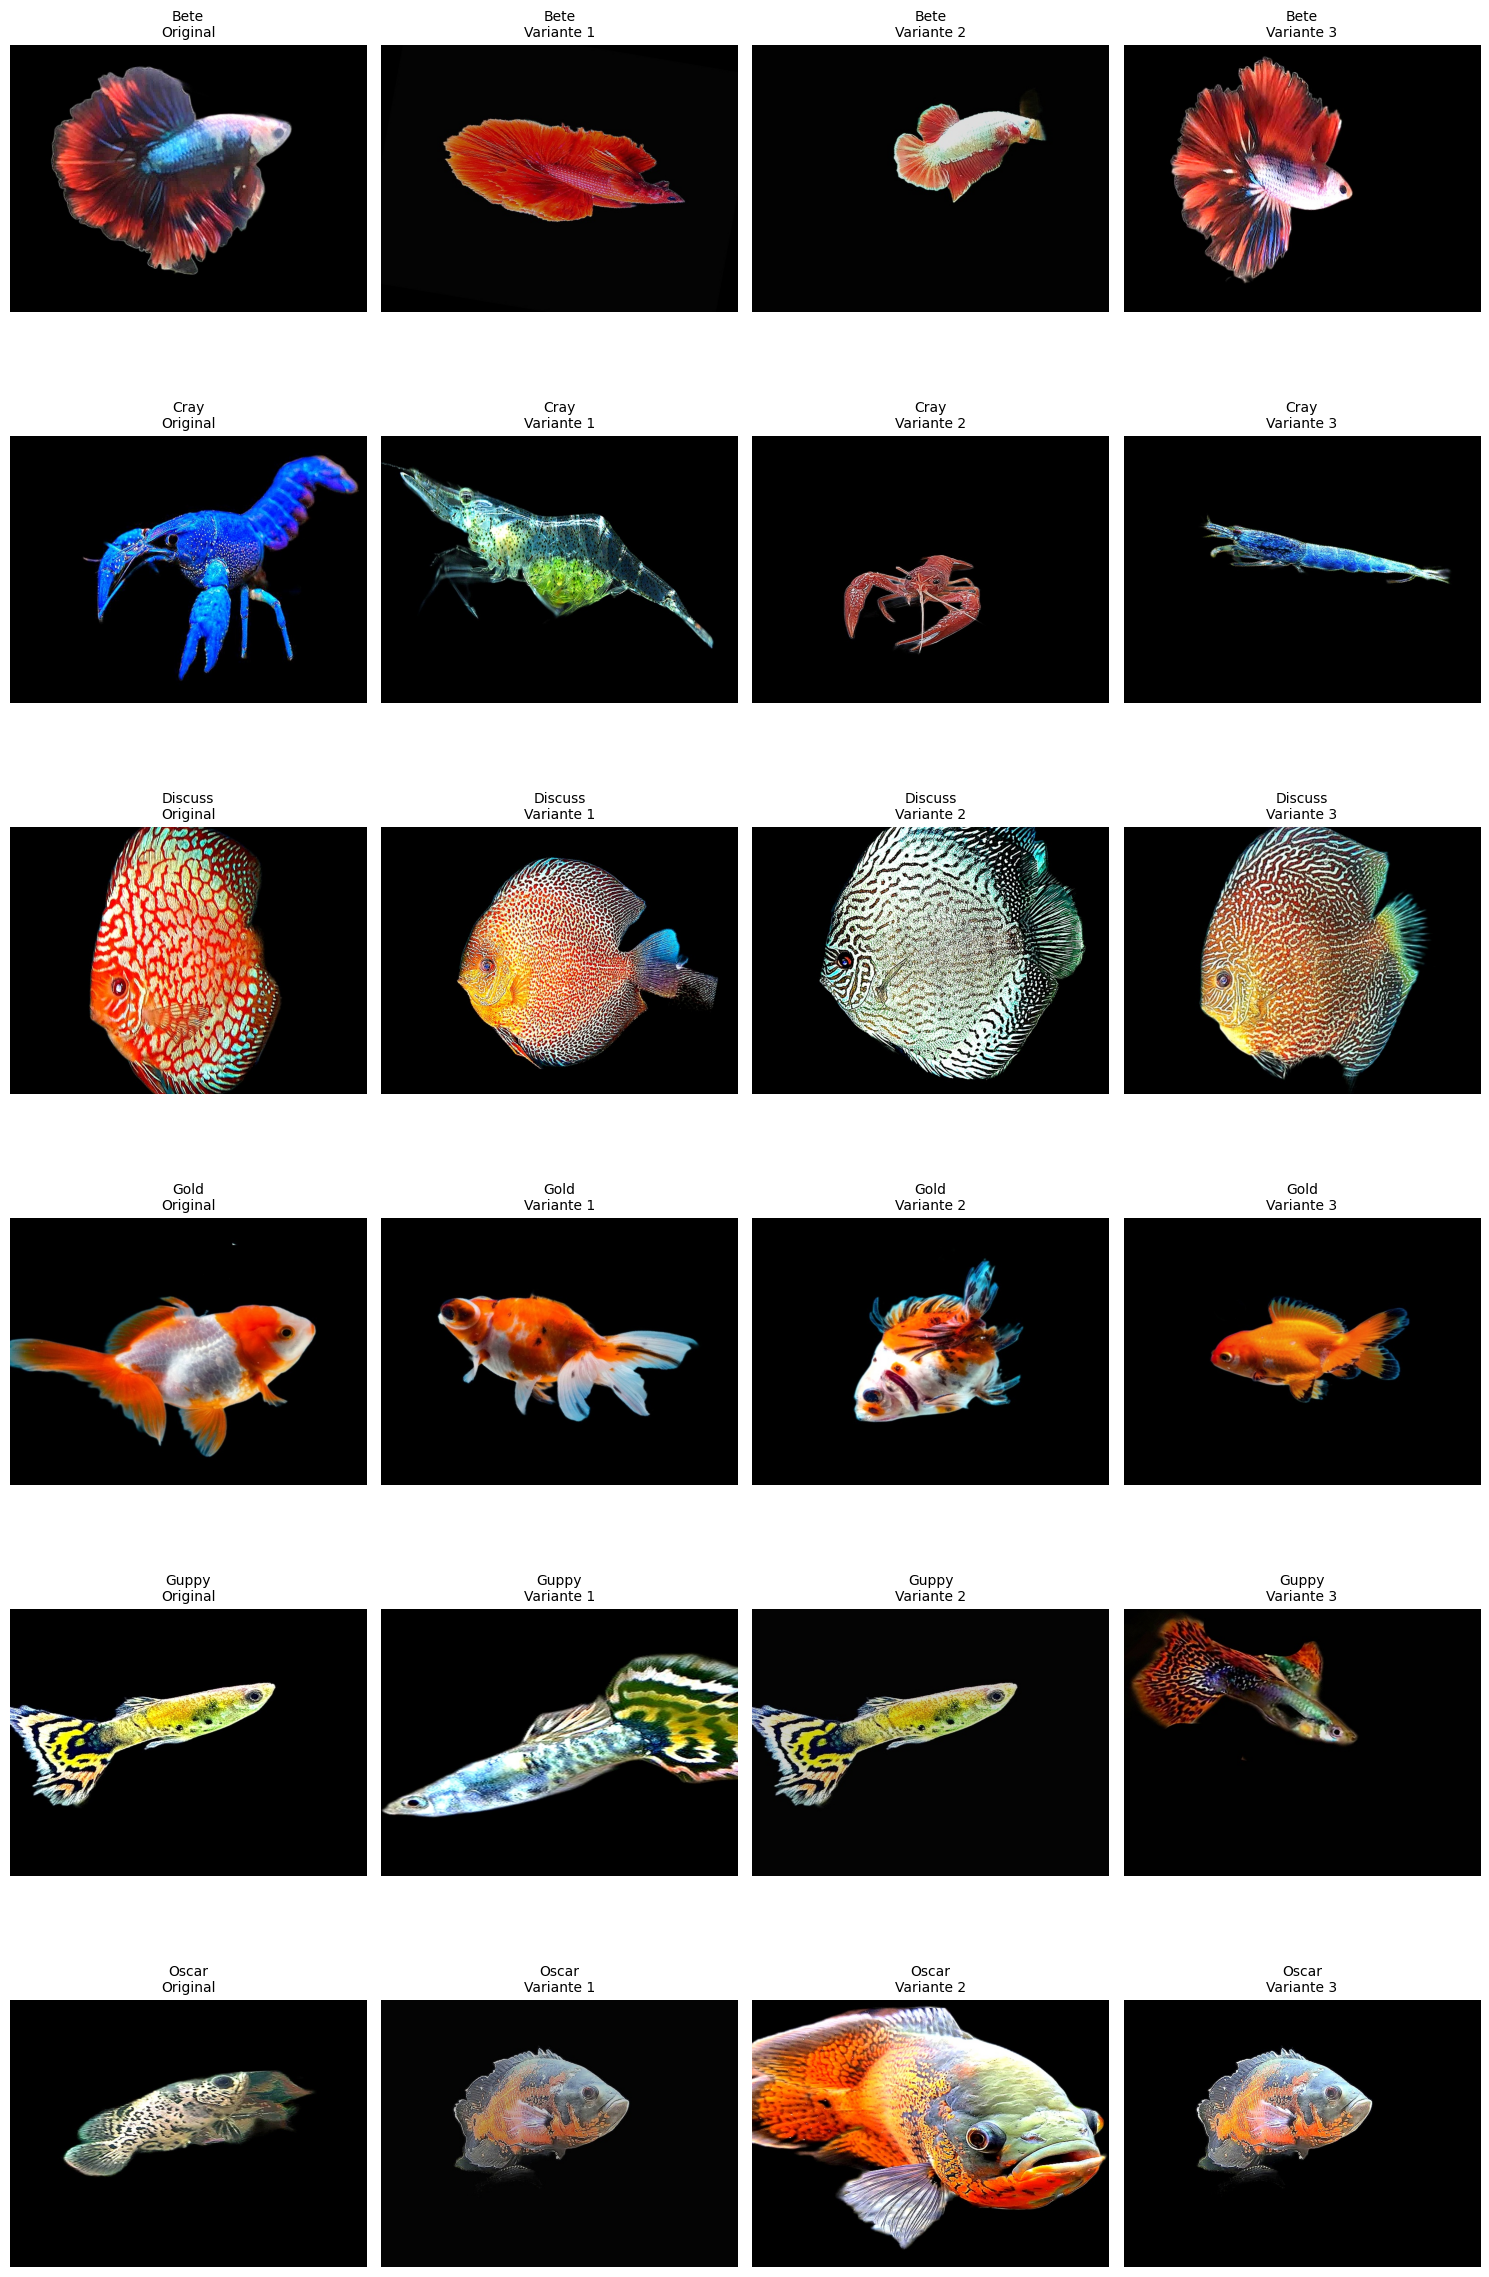

In [5]:
import os
import torch
from PIL import Image, ImageEnhance, ImageFilter
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, ConcatDataset
import numpy as np
import random
import matplotlib.pyplot as plt

# ============================================
# 1. CONFIGURACIÓN INICIAL
# ============================================
data_dir = "/kaggle/input/datasets/jannatulferdaues/aquarium-fish-classification/Final (°_°)"
output_dir = "/kaggle/working/augmented_dataset"  # Donde guardar las imágenes aumentadas

# Configuración de variantes por clase
variants_config = {
    'Bete': 9,
    'Cray': 22,
    'Discuss': 8,
    'Gold': 8,
    'Guppy': 8,
    'Oscar': 13
}

# ============================================
# 2. FUNCIONES DE AUMENTACIÓN CON PIL
# ============================================
def apply_augmentations(image, num_variants):
    """
    Aplica múltiples aumentaciones a una imagen usando PIL
    Retorna una lista de imágenes aumentadas
    """
    augmented_images = []
    
    # Guardar la imagen original
    augmented_images.append(image.copy())
    
    # Generar variantes
    for i in range(num_variants - 1):  # -1 porque ya tenemos la original
        img = image.copy()
        
        # Seleccionar aleatoriamente qué aumentaciones aplicar
        aug_type = random.choice(['rotation', 'flip', 'brightness', 'contrast', 
                                 'sharpness', 'color', 'blur', 'combined'])
        
        # Rotación
        if aug_type == 'rotation' or random.random() < 0.3:
            angle = random.choice([-15, -10, -5, 5, 10, 15, 20, 90, 180, 270])
            img = img.rotate(angle, expand=True, fillcolor=(0, 0, 0))
            # Redimensionar al tamaño original (si expand=True cambia el tamaño)
            if angle in [90, 180, 270]:
                img = img.resize(image.size, Image.Resampling.LANCZOS)
        
        # Flip horizontal
        if aug_type == 'flip' or random.random() < 0.3:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        
        # Flip vertical
        if random.random() < 0.15:
            img = img.transpose(Image.FLIP_TOP_BOTTOM)
        
        # Brillo
        if aug_type == 'brightness' or random.random() < 0.2:
            enhancer = ImageEnhance.Brightness(img)
            factor = random.uniform(0.7, 1.3)
            img = enhancer.enhance(factor)
        
        # Contraste
        if aug_type == 'contrast' or random.random() < 0.2:
            enhancer = ImageEnhance.Contrast(img)
            factor = random.uniform(0.7, 1.3)
            img = enhancer.enhance(factor)
        
        # Nitidez (Sharpness)
        if aug_type == 'sharpness' or random.random() < 0.15:
            enhancer = ImageEnhance.Sharpness(img)
            factor = random.uniform(0.5, 1.5)
            img = enhancer.enhance(factor)
        
        # Color
        if aug_type == 'color' or random.random() < 0.15:
            enhancer = ImageEnhance.Color(img)
            factor = random.uniform(0.7, 1.3)
            img = enhancer.enhance(factor)
        
        # Desenfoque (Blur)
        if aug_type == 'blur' or random.random() < 0.1:
            img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 2.0)))
        
        # Combinación de varias aumentaciones
        if aug_type == 'combined':
            # Aplicar múltiples aumentaciones en secuencia
            if random.random() < 0.5:
                angle = random.choice([-10, -5, 5, 10])
                img = img.rotate(angle, expand=False)
            
            if random.random() < 0.5:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
            
            if random.random() < 0.3:
                enhancer = ImageEnhance.Brightness(img)
                img = enhancer.enhance(random.uniform(0.8, 1.2))
            
            if random.random() < 0.3:
                enhancer = ImageEnhance.Contrast(img)
                img = enhancer.enhance(random.uniform(0.8, 1.2))
        
        # Asegurar que la imagen mantenga el tamaño original
        if img.size != image.size:
            img = img.resize(image.size, Image.Resampling.LANCZOS)
        
        augmented_images.append(img)
    
    return augmented_images

# ============================================
# 3. PROCESAR Y GUARDAR IMÁGENES AUMENTADAS
# ============================================
def augment_and_save_dataset(input_dir, output_dir, variants_config):
    """
    Procesa todas las imágenes del dataset, aplica aumentaciones y las guarda
    """
    os.makedirs(output_dir, exist_ok=True)
    
    total_images = 0
    stats = {}
    
    for class_name, num_variants in variants_config.items():
        class_input_path = os.path.join(input_dir, class_name)
        class_output_path = os.path.join(output_dir, class_name)
        os.makedirs(class_output_path, exist_ok=True)
        
        if not os.path.exists(class_input_path):
            print(f"⚠️ Advertencia: No se encontró la clase {class_name}")
            continue
        
        # Obtener todas las imágenes de la clase
        image_files = [f for f in os.listdir(class_input_path) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        print(f"\n📁 Procesando {class_name}: {len(image_files)} imágenes originales")
        print(f"   Creando {num_variants} variantes por imagen")
        
        class_count = 0
        for idx, img_file in enumerate(image_files):
            img_path = os.path.join(class_input_path, img_file)
            
            try:
                # Cargar imagen original
                img = Image.open(img_path)
                
                # Aplicar aumentaciones
                augmented_images = apply_augmentations(img, num_variants)
                
                # Guardar cada variante
                for aug_idx, aug_img in enumerate(augmented_images):
                    # Nombre: original_filename_variant_X.ext
                    name, ext = os.path.splitext(img_file)
                    new_filename = f"{name}_v{aug_idx:02d}{ext}"
                    save_path = os.path.join(class_output_path, new_filename)
                    aug_img.save(save_path, quality=95)
                    class_count += 1
                    
            except Exception as e:
                print(f"   ❌ Error con {img_file}: {e}")
                continue
        
        stats[class_name] = {
            'original': len(image_files),
            'generated': class_count,
            'variants_per_image': num_variants
        }
        total_images += class_count
        
        print(f"   ✅ {class_name}: {class_count} imágenes generadas")
    
    return stats, total_images

# ============================================
# 4. EJECUTAR AUMENTACIÓN
# ============================================
print("🚀 Iniciando Data Augmentation...")
print("=" * 50)

stats, total_images = augment_and_save_dataset(data_dir, output_dir, variants_config)

print("\n" + "=" * 50)
print("📊 RESUMEN DE AUMENTACIÓN:")
print("=" * 50)
for class_name, class_stats in stats.items():
    print(f"{class_name}:")
    print(f"  - Originales: {class_stats['original']}")
    print(f"  - Generadas: {class_stats['generated']}")
    print(f"  - Variantes por imagen: {class_stats['variants_per_image']}")
print(f"\n✅ Total imágenes generadas: {total_images}")

# ============================================
# 5. VERIFICAR ALGUNAS IMÁGENES AUMENTADAS
# ============================================
def visualize_augmented_samples(output_dir, classes, num_samples=3):
    """
    Muestra ejemplos de imágenes aumentadas para cada clase
    """
    fig, axes = plt.subplots(len(classes), num_samples + 1, 
                             figsize=(15, 4 * len(classes)))
    
    for row, class_name in enumerate(classes):
        class_path = os.path.join(output_dir, class_name)
        if not os.path.exists(class_path):
            continue
            
        images = [f for f in os.listdir(class_path) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        # Mostrar algunas variantes
        for col in range(num_samples + 1):
            if col == 0:
                # Mostrar una original (v00)
                img_file = [f for f in images if '_v00.' in f][0]
                title = "Original"
            else:
                # Mostrar variantes
                variant_files = [f for f in images if f'_v{col:02d}.' in f]
                if variant_files:
                    img_file = variant_files[0]
                    title = f"Variante {col}"
                else:
                    continue
            
            img_path = os.path.join(class_path, img_file)
            img = Image.open(img_path)
            
            axes[row, col].imshow(img)
            axes[row, col].set_title(f"{class_name}\n{title}", fontsize=10)
            axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/augmentation_samples.png', dpi=150)
    plt.show()

# Visualizar ejemplos
classes = list(variants_config.keys())
visualize_augmented_samples(output_dir, classes, num_samples=3)


In [6]:
# ============================================
# 6. CARGAR DATASET AUMENTADO PARA PYTORCH
# ============================================
# Transformaciones para entrenamiento (sin aumentar más, solo normalizar)
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Cargar dataset aumentado
augmented_dataset = datasets.ImageFolder(
    root=output_dir,
    transform=transform_train
)

print(f"\n📊 Dataset aumentado cargado:")
print(f"Total imágenes: {len(augmented_dataset)}")
print(f"Clases: {augmented_dataset.classes}")
print(f"Mapeo: {augmented_dataset.class_to_idx}")


📊 Dataset aumentado cargado:
Total imágenes: 10167
Clases: ['Bete', 'Cray', 'Discuss', 'Gold', 'Guppy', 'Oscar']
Mapeo: {'Bete': 0, 'Cray': 1, 'Discuss': 2, 'Gold': 3, 'Guppy': 4, 'Oscar': 5}


In [7]:
# ============================================
# 7. DIVIDIR EN TRAIN/VAL/TEST
# ============================================
# Dividir el dataset
total_size = len(augmented_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    augmented_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # Para reproducibilidad
)

print(f"\n📊 Distribución del dataset aumentado:")
print(f"Train: {len(train_dataset)} imágenes ({train_size/total_size*100:.1f}%)")
print(f"Val: {len(val_dataset)} imágenes ({val_size/total_size*100:.1f}%)")
print(f"Test: {len(test_dataset)} imágenes ({test_size/total_size*100:.1f}%)")


📊 Distribución del dataset aumentado:
Train: 7116 imágenes (70.0%)
Val: 1525 imágenes (15.0%)
Test: 1526 imágenes (15.0%)


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# ============================================
# 1. CARGAR EL DATASET AUMENTADO
# ============================================
print("🚀 Cargando dataset aumentado...")

# Directorio del dataset aumentado
data_dir = "/kaggle/working/augmented_dataset"  # O la ruta donde guardaste las imágenes aumentadas

# Transformaciones
transform = transforms.Compose([
    transforms.Resize((224, 224)),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Cargar dataset completo
full_dataset = torchvision.datasets.ImageFolder(
    root=data_dir,
    transform=transform
)

# Obtener clases
classes = full_dataset.classes
num_classes = len(classes)
print(f"📊 Dataset cargado: {len(full_dataset)} imágenes")
print(f"📋 Clases: {classes}")
print(f"🔢 Total clases: {num_classes}")

# ============================================
# 2. DIVIDIR EN TRAIN/VAL/TEST
# ============================================
# Dividir en conjuntos
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"\n📊 Distribución:")
print(f"Train: {len(train_dataset)} imágenes ({train_size/total_size*100:.1f}%)")
print(f"Val: {len(val_dataset)} imágenes ({val_size/total_size*100:.1f}%)")
print(f"Test: {len(test_dataset)} imágenes ({test_size/total_size*100:.1f}%)")

🚀 Cargando dataset aumentado...
📊 Dataset cargado: 10167 imágenes
📋 Clases: ['Bete', 'Cray', 'Discuss', 'Gold', 'Guppy', 'Oscar']
🔢 Total clases: 6

📊 Distribución:
Train: 7116 imágenes (70.0%)
Val: 1525 imágenes (15.0%)
Test: 1526 imágenes (15.0%)


In [11]:
# ============================================
# 3. CREAR DATALOADERS
# ============================================
batch_size = 32

dataloader = {
    'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
    'val': DataLoader(val_dataset, batch_size=1000, shuffle=False),
    'test': DataLoader(test_dataset, batch_size=1000, shuffle=False)
}

print(f"\n✅ DataLoaders creados:")
print(f"Train batches: {len(dataloader['train'])}")
print(f"Val batches: {len(dataloader['val'])}")
print(f"Test batches: {len(dataloader['test'])}")



✅ DataLoaders creados:
Train batches: 223
Val batches: 2
Test batches: 2


In [ ]:
# 4. FUNCIONES AUXILIARES
# ============================================
def softmax(x):
    """Función softmax para probabilidades"""
    return torch.exp(x) / torch.exp(x).sum(axis=-1, keepdims=True)

def build_model(input_size=32*32*3, hidden_size=512, num_classes=num_classes):
    """Construye el modelo multicapa"""
    model = torch.nn.Sequential(
        torch.nn.Linear(input_size, hidden_size),
        torch.nn.ReLU(),
        torch.nn.Dropout(0.3),  # Regularización
        torch.nn.Linear(hidden_size, hidden_size//2),
        torch.nn.ReLU(),
        torch.nn.Dropout(0.3),
        torch.nn.Linear(hidden_size//2, num_classes)
    )
    return model.to(device)

def get_accuracy(y_true, y_pred):
    """Calcula la precisión"""
    return accuracy_score(y_true.cpu().numpy(), y_pred.cpu().numpy())

In [18]:
# ============================================
# 5. FUNCIÓN DE ENTRENAMIENTO (ADAPTADA)
# ============================================
def fit(model, dataloader, optimizer, epochs=100, log_each=10, early_stopping=5):
    """
    Función de entrenamiento adaptada para CPU/GPU
    """
    criterion = torch.nn.CrossEntropyLoss()
    
    # Listas para guardar métricas
    loss, acc = [], []
    val_loss, val_acc = [], []
    
    # Mejor modelo
    best_acc = 0
    step = 0
    best_epoch = 0
    
    print("\n🚀 Iniciando entrenamiento...")
    print("=" * 60)
    
    for epoch in range(1, epochs + 1):
        # ===== FASE DE ENTRENAMIENTO =====
        model.train()
        epoch_loss = []
        epoch_acc = []
        
        for x_b, y_b in dataloader['train']:
            # Mover datos al dispositivo y aplanar
            x_b = x_b.to(device).view(-1, 32*32*3)
            y_b = y_b.to(device)
            
            # Forward pass
            y_pred = model(x_b)
            loss_value = criterion(y_pred, y_b)
            
            # Backward pass
            optimizer.zero_grad()
            loss_value.backward()
            optimizer.step()
            
            # Métricas
            epoch_loss.append(loss_value.item())
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            epoch_acc.append(get_accuracy(y_b, y_probas))
        
        # Métricas promedio de entrenamiento
        loss.append(np.mean(epoch_loss))
        acc.append(np.mean(epoch_acc))
        
        # ===== FASE DE VALIDACIÓN =====
        model.eval()
        val_epoch_loss = []
        val_epoch_acc = []
        
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                x_b = x_b.to(device).view(-1, 32*32*3)
                y_b = y_b.to(device)
                
                y_pred = model(x_b)
                loss_value = criterion(y_pred, y_b)
                
                val_epoch_loss.append(loss_value.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                val_epoch_acc.append(get_accuracy(y_b, y_probas))
        
        val_loss.append(np.mean(val_epoch_loss))
        val_acc.append(np.mean(val_epoch_acc))
        
        # ===== GUARDAR MEJOR MODELO =====
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            best_epoch = epoch
            torch.save(model.state_dict(), 'best_model.pt')
            step = 0
            print(f"⭐ Mejor modelo guardado con acc: {best_acc:.5f} en epoch {epoch}")
        
        step += 1
        
        # ===== EARLY STOPPING =====
        if early_stopping and step > early_stopping:
            print(f"⏹️ Entrenamiento detenido en epoch {epoch} por no mejorar en {early_stopping} epochs seguidas")
            break
        
        # ===== LOGGING =====
        if epoch % log_each == 0:
            print(f"Epoch {epoch:3d}/{epochs} | Loss: {loss[-1]:.5f} | Acc: {acc[-1]:.5f} | Val_Loss: {val_loss[-1]:.5f} | Val_Acc: {val_acc[-1]:.5f}")
    
    # Cargar mejor modelo
    model.load_state_dict(torch.load('best_model.pt'))
    print(f"\n✅ Mejor modelo cargado (epoch {best_epoch} con val_acc: {best_acc:.5f})")
    
    return {
        'epoch': list(range(1, len(loss) + 1)),
        'loss': loss,
        'acc': acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'best_epoch': best_epoch,
        'best_acc': best_acc
    }

In [15]:
# ============================================
# 0. CONFIGURAR DISPOSITIVO (CPU/GPU)
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Dispositivo a usar: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   ⚠️ Usando CPU - El entrenamiento será más lento")


🔧 Dispositivo a usar: cpu
   ⚠️ Usando CPU - El entrenamiento será más lento


In [19]:
# ============================================
# 6. ENTRENAR EL MODELO
# ============================================
# Configuración
INPUT_SIZE = 32 * 32 * 3
HIDDEN_SIZE = 512
NUM_CLASSES = num_classes
LEARNING_RATE = 0.001
EPOCHS = 50  # Reducimos épocas para CPU
EARLY_STOPPING = 10

# Construir modelo
model = build_model(INPUT_SIZE, HIDDEN_SIZE, NUM_CLASSES)
print(f"\n📐 Modelo construido:")
print(f"Input size: {INPUT_SIZE}")
print(f"Hidden size: {HIDDEN_SIZE}")
print(f"Output classes: {NUM_CLASSES}")
print(f"Total parámetros: {sum(p.numel() for p in model.parameters()):,}")
print(f"Dispositivo: {device}")

# Optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Entrenar
history = fit(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    epochs=EPOCHS,
    log_each=5,
    early_stopping=EARLY_STOPPING
)



📐 Modelo construido:
Input size: 3072
Hidden size: 512
Output classes: 6
Total parámetros: 1,706,246
Dispositivo: cpu

🚀 Iniciando entrenamiento...
⭐ Mejor modelo guardado con acc: 0.53952 en epoch 1
⭐ Mejor modelo guardado con acc: 0.56250 en epoch 2
⭐ Mejor modelo guardado con acc: 0.58369 en epoch 3
⭐ Mejor modelo guardado con acc: 0.64050 en epoch 4
Epoch   5/50 | Loss: 1.07678 | Acc: 0.58497 | Val_Loss: 1.00875 | Val_Acc: 0.63169
⭐ Mejor modelo guardado con acc: 0.65000 en epoch 6
⭐ Mejor modelo guardado con acc: 0.66533 en epoch 7
⭐ Mejor modelo guardado con acc: 0.68490 en epoch 8
Epoch  10/50 | Loss: 0.92632 | Acc: 0.64845 | Val_Loss: 0.82838 | Val_Acc: 0.67793
⭐ Mejor modelo guardado con acc: 0.71069 en epoch 11
⭐ Mejor modelo guardado con acc: 0.71329 en epoch 12
⭐ Mejor modelo guardado con acc: 0.71831 en epoch 13
Epoch  15/50 | Loss: 0.84552 | Acc: 0.68073 | Val_Loss: 0.79348 | Val_Acc: 0.71429
⭐ Mejor modelo guardado con acc: 0.72912 en epoch 16
⭐ Mejor modelo guardado co


📊 EVALUANDO EN TEST...
Test Loss: 0.57474
Test Accuracy: 0.79904 (79.90%)

📊 Matriz de Confusión:


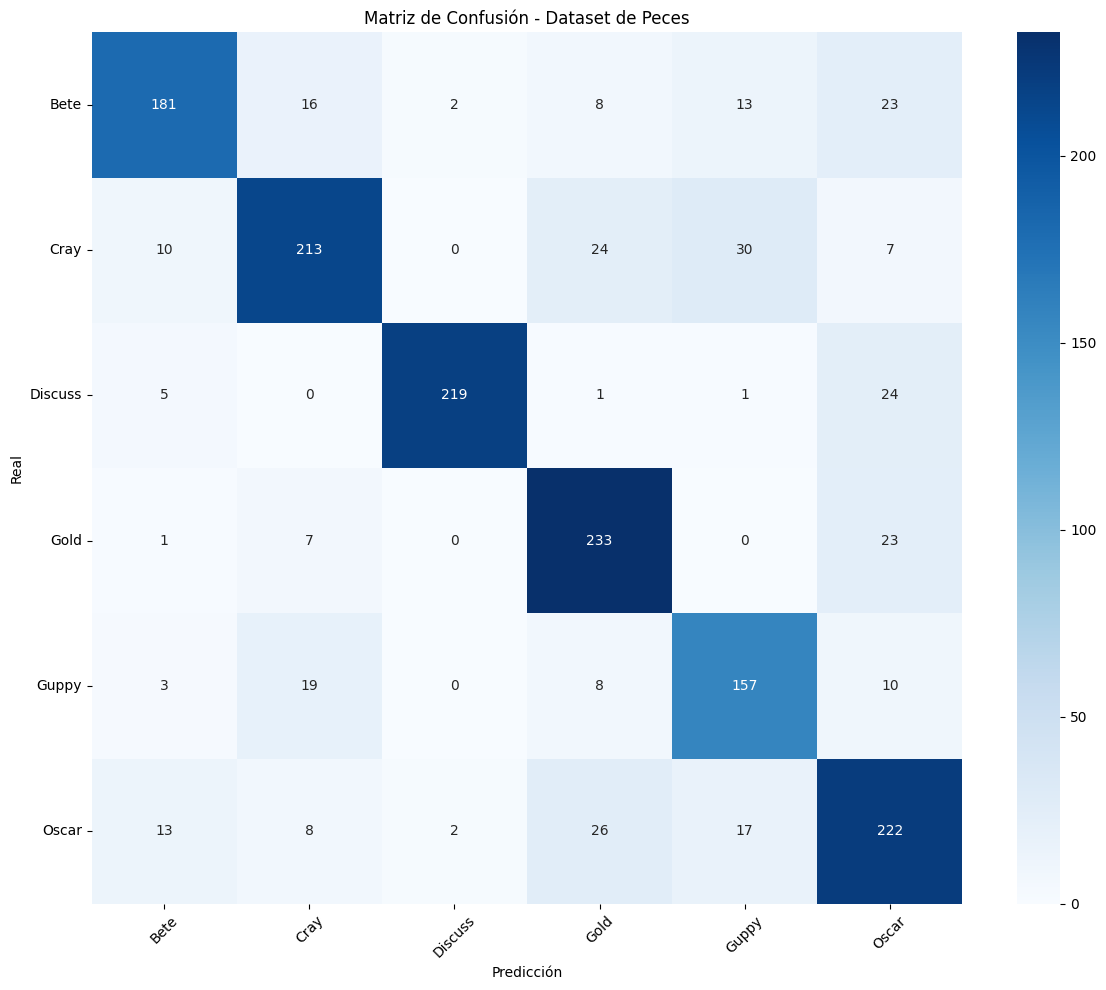


📋 Reporte de Clasificación:
              precision    recall  f1-score   support

        Bete       0.85      0.74      0.79       243
        Cray       0.81      0.75      0.78       284
     Discuss       0.98      0.88      0.93       250
        Gold       0.78      0.88      0.83       264
       Guppy       0.72      0.80      0.76       197
       Oscar       0.72      0.77      0.74       288

    accuracy                           0.80      1526
   macro avg       0.81      0.80      0.80      1526
weighted avg       0.81      0.80      0.80      1526


📈 Visualizando métricas...


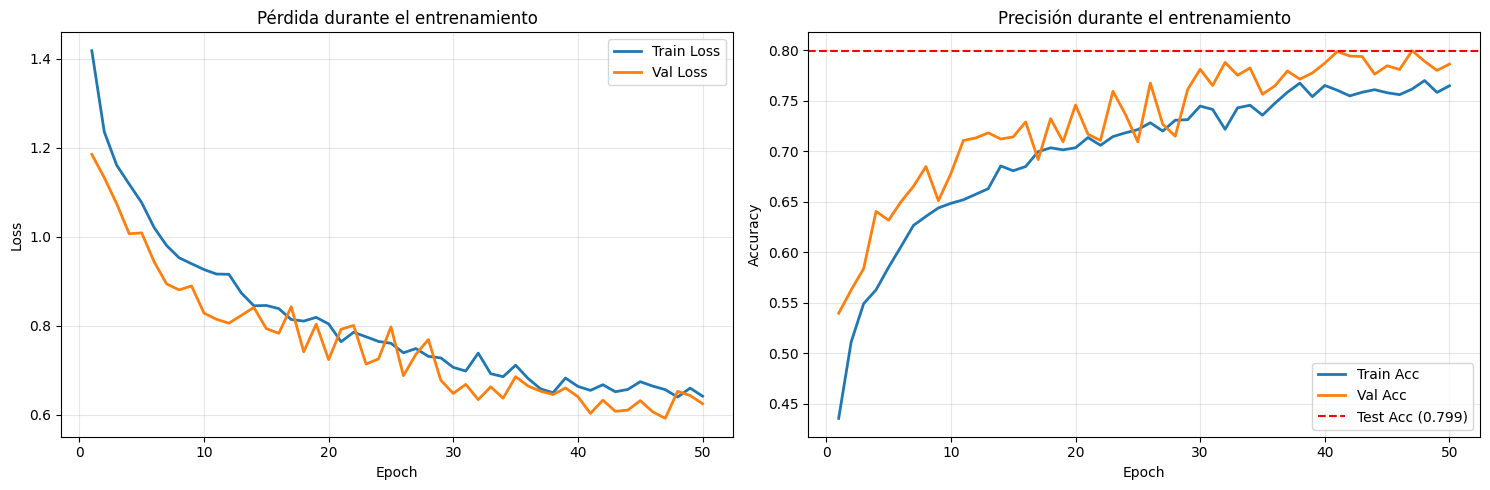

In [20]:
# ============================================
# 7. EVALUAR EN TEST
# ============================================
print("\n" + "=" * 60)
print("📊 EVALUANDO EN TEST...")
print("=" * 60)

model.eval()
test_loss = []
test_acc = []
all_preds = []
all_labels = []

with torch.no_grad():
    for x_b, y_b in dataloader['test']:
        x_b = x_b.to(device).view(-1, 32*32*3)
        y_b = y_b.to(device)
        
        y_pred = model(x_b)
        loss_value = torch.nn.CrossEntropyLoss()(y_pred, y_b)
        
        test_loss.append(loss_value.item())
        y_probas = torch.argmax(softmax(y_pred), axis=1)
        test_acc.append(get_accuracy(y_b, y_probas))
        
        all_preds.extend(y_probas.cpu().numpy())
        all_labels.extend(y_b.cpu().numpy())

test_loss_mean = np.mean(test_loss)
test_acc_mean = np.mean(test_acc)

print(f"Test Loss: {test_loss_mean:.5f}")
print(f"Test Accuracy: {test_acc_mean:.5f} ({test_acc_mean*100:.2f}%)")

# ============================================
# 8. MATRIZ DE CONFUSIÓN
# ============================================
print("\n📊 Matriz de Confusión:")
print("=" * 60)

# Crear matriz de confusión
cm = confusion_matrix(all_labels, all_preds)

# Visualizar
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusión - Dataset de Peces')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

# ============================================
# 9. REPORTE DE CLASIFICACIÓN
# ============================================
print("\n📋 Reporte de Clasificación:")
print("=" * 60)

report = classification_report(all_labels, all_preds, target_names=classes)
print(report)

# Guardar reporte
with open('/kaggle/working/classification_report.txt', 'w') as f:
    f.write(report)

# ============================================
# 10. VISUALIZACIÓN DE MÉTRICAS
# ============================================
print("\n📈 Visualizando métricas...")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history['epoch'], history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['epoch'], history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Pérdida durante el entrenamiento')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['epoch'], history['acc'], label='Train Acc', linewidth=2)
axes[1].plot(history['epoch'], history['val_acc'], label='Val Acc', linewidth=2)
axes[1].axhline(y=test_acc_mean, color='red', linestyle='--', label=f'Test Acc ({test_acc_mean:.3f})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Precisión durante el entrenamiento')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_metrics.png', dpi=150)
plt.show()

In [21]:
# ============================================
# 11. GUARDAR RESULTADOS
# ============================================
print("\n💾 Guardando resultados...")

# Guardar modelo completo
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'classes': classes,
    'history': history,
    'test_acc': test_acc_mean,
    'test_loss': test_loss_mean
}, '/kaggle/working/final_model.pth')

# Guardar resumen
with open('/kaggle/working/training_summary.txt', 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("RESUMEN DE ENTRENAMIENTO\n")
    f.write("=" * 60 + "\n\n")
    
    f.write(f"Dataset: {data_dir}\n")
    f.write(f"Total imágenes: {total_size}\n")
    f.write(f"Clases: {', '.join(classes)}\n")
    f.write(f"Número de clases: {num_classes}\n\n")
    
    f.write(f"Distribución:\n")
    f.write(f"  Train: {len(train_dataset)} ({len(train_dataset)/total_size*100:.1f}%)\n")
    f.write(f"  Val: {len(val_dataset)} ({len(val_dataset)/total_size*100:.1f}%)\n")
    f.write(f"  Test: {len(test_dataset)} ({len(test_dataset)/total_size*100:.1f}%)\n\n")
    
    f.write(f"Mejor val_acc: {history['best_acc']:.5f} (epoch {history['best_epoch']})\n")
    f.write(f"Test accuracy: {test_acc_mean:.5f} ({test_acc_mean*100:.2f}%)\n")
    f.write(f"Test loss: {test_loss_mean:.5f}\n\n")
    
    f.write("Reporte de clasificación:\n")
    f.write("=" * 60 + "\n")
    f.write(report)

print("\n" + "=" * 60)
print("🎉 ¡ENTRENAMIENTO COMPLETADO EXITOSAMENTE!")
print("=" * 60)
print("\n📁 Archivos guardados:")
print("  - best_model.pt (mejor modelo)")
print("  - final_model.pth (modelo completo)")
print("  - confusion_matrix.png")
print("  - training_metrics.png")
print("  - classification_report.txt")
print("  - training_summary.txt")


💾 Guardando resultados...

🎉 ¡ENTRENAMIENTO COMPLETADO EXITOSAMENTE!

📁 Archivos guardados:
  - best_model.pt (mejor modelo)
  - final_model.pth (modelo completo)
  - confusion_matrix.png
  - training_metrics.png
  - classification_report.txt
  - training_summary.txt
